In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [158]:
path= 'online_retail_II.xlsx'
data= pd.read_excel(path)
df= data.copy()

### EDA

In [159]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [160]:
print('shape',df.shape)
print('duplicates',df.duplicated().sum())
print('__________________\nnan\n',df.isna().sum())

shape (525461, 8)
duplicates 6865
__________________
nan
 Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [161]:
# Check for invoices with mixed NaN and non-NaN Customer IDs
mixed_invoices = df.groupby('Invoice')['Customer ID'].apply(
    lambda x: x.isnull().any() and x.notnull().any()
)

print(f"Invoices with partial missing IDs: {mixed_invoices.sum()}")

Invoices with partial missing IDs: 0


**Dropping duplicates**

In [162]:
# filtering out redundant features
df= df[['Invoice', 'StockCode','Quantity', 'InvoiceDate','Price', 'Customer ID']]
# dropping duplicates
df= df.drop_duplicates()
df= df.reset_index(drop=True)

**Invoice Cleaning**

In [163]:
# 1. Create a boolean mask: True if Invoice is exactly 6 digits
# ^ = start, \d{6} = six digits, $ = end
mask = df['Invoice'].astype(str).str.match(r'^\d{6}$')

# 2. Calculate percentages
stats = mask.value_counts(normalize=True) * 100

print(f"✅ 6-digit Invoices (Standard): {stats.get(True, 0):.2f}%")
print(f"❌ Non 6-digit Invoices (Outliers/Cancellations): {stats.get(False, 0):.2f}%")

# 3. View examples of non-matches
print("\nUnique examples of non-matching Invoices:")
print(df[~mask]['Invoice'].unique())

✅ 6-digit Invoices (Standard): 98.04%
❌ Non 6-digit Invoices (Outliers/Cancellations): 1.96%

Unique examples of non-matching Invoices:
['C489449' 'C489459' 'C489476' ... 'C538123' 'C538124' 'C538164']


In [164]:
# Filtering for invoices that start with 'C'
cancelled_df = df[df['Invoice'].str.startswith('C', na=False)]
cancelled_df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID
178,C489449,22087,-12,2009-12-01 10:33:00,2.95,16321.0
179,C489449,85206A,-6,2009-12-01 10:33:00,1.65,16321.0
180,C489449,21895,-4,2009-12-01 10:33:00,4.25,16321.0
181,C489449,21896,-6,2009-12-01 10:33:00,2.10,16321.0
182,C489449,22083,-12,2009-12-01 10:33:00,2.95,16321.0


In [165]:
# Get the unique non-matching values
non_matching_array = df[~mask]['Invoice'].unique()

# Filter the array to exclude those starting with 'C'
filtered_array = [code for code in non_matching_array if not str(code).startswith('C')]

print(filtered_array)

['A506401', 'A516228', 'A528059']


In [166]:
# Filtering for invoices that start with 'A'
cancelled_df = df[df['Invoice'].str.startswith('A', na=False)]
cancelled_df

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID
177338,A506401,B,1,2010-04-29 13:36:00,-53594.36,NaN
273025,A516228,B,1,2010-07-19 11:24:00,-44031.79,NaN
398731,A528059,B,1,2010-10-20 12:04:00,-38925.87,NaN


In [167]:
#dropping invoices that aren't within the 6 digit frame
df = df[df['Invoice'].astype(str).str.match(r'^\d{6}$')]

# Reset index to ensure a clean sequence
df = df.reset_index(drop=True)

print(f"New shape: {df.shape}")

New shape: (508411, 6)


**StockCode Cleaning**

In [168]:
# Create a mask: True if StockCode is exactly 5 digits
stock_mask = df['StockCode'].astype(str).str.match(r'^\d{5}$')

# Calculate percentages
stock_stats = stock_mask.value_counts(normalize=True) * 100

print(f"✅ 5-digit StockCodes (Standard): {stock_stats.get(True, 0):.2f}%")
print(f"❌ Non 5-digit StockCodes (Special/Alphanumeric): {stock_stats.get(False, 0):.2f}%")

# Display unique examples of non-matching StockCodes
print("\nUnique non-standard StockCodes:")
print(df[~stock_mask]['StockCode'].unique().tolist())

✅ 5-digit StockCodes (Standard): 84.83%
❌ Non 5-digit StockCodes (Special/Alphanumeric): 15.17%

Unique non-standard StockCodes:
['79323P', '79323W', '48173C', '35004B', '84596F', '84596L', '84507B', '84970S', '84031A', '84031B', '84032A', '84032B', '84519A', '84519B', '85132A', '85132C', '85183A', '85183B', '85014A', '85014B', '16161P', '16169N', '85232B', 'POST', '84029E', '84899E', '85123A', '84251J', '82001S', '35916C', '35916B', '18097C', '85099B', '85206A', '79323S', '85071A', '85071B', '82494L', '90200D', '90200E', '90200A', '90200C', '90200B', '90185C', '90185B', '90003C', '90003D', '90003B', '90209C', '90209A', '90082D', '72760B', '84327A', '84997D', '84997C', '90121B', '90175A', '90195B', '47566B', '47591D', '82613D', '84849B', '84997A', '16207A', '47591A', '84997B', '84951A', '85129A', '82616B', '84912B', '85014C', '85014D', '84971L', '84884A', '90013C', '90067A', '90067B', '90000A', '90024B', '90036D', '90199C', '35751C', '72739B', '85232D', '37492A', '84029G', '37492C', '8

In [169]:
pattern = r'^[a-zA-Z]\d{5}$|^\d{5}[a-zA-Z]$'

# Create an independent deep copy
ac_df = df[df['StockCode'].astype(str).str.match(pattern)].dropna().copy()

In [170]:
# 1. Define the "Standard" patterns to exclude
standard_5d = r'^\d{5}$'
alphanumeric_6c = r'^[a-zA-Z]\d{5}$|^\d{5}[a-zA-Z]$'

# 2. Create the mask for what we WANT to exclude
standard_mask = df['StockCode'].astype(str).str.match(standard_5d) | \
                df['StockCode'].astype(str).str.match(alphanumeric_6c)

# 3. Use the Tilde (~) to select everything else (the outliers)
special_codes_df = df[~standard_mask].dropna().copy()

# Display unique values first to see what we found
print(special_codes_df['StockCode'].unique())

# Display the dataframe
special_codes_df

['POST' '79323LP' '15056BL' '79323GR' 'C2' 'M' 'BANK CHARGES' 'TEST001'
 'TEST002' 'PADS' 'ADJUST' 'D' 'ADJUST2' 'SP1002']


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID
89,489439,POST,3,2009-12-01 09:28:00,18.00,12682.0
126,489444,POST,1,2009-12-01 09:55:00,141.00,12636.0
173,489447,POST,1,2009-12-01 10:10:00,130.00,12362.0
535,489522,79323LP,1,2009-12-01 11:45:00,6.75,15998.0
572,489526,15056BL,6,2009-12-01 11:50:00,5.95,12533.0
...,...,...,...,...,...,...
505998,538003,POST,8,2010-12-09 12:05:00,18.00,12429.0
506088,538008,POST,5,2010-12-09 12:17:00,18.00,12683.0
507449,538093,15056BL,12,2010-12-09 14:49:00,5.95,12682.0
507478,538093,POST,5,2010-12-09 14:49:00,18.00,12682.0


In [171]:
prod_variants= ['79323LP','15056BL','79323GR']
special_codes_df[special_codes_df['StockCode'].isin(prod_variants)]

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID
535,489522,79323LP,1,2009-12-01 11:45:00,6.75,15998.0
572,489526,15056BL,6,2009-12-01 11:50:00,5.95,12533.0
2995,489658,15056BL,12,2009-12-01 17:31:00,5.95,15485.0
3011,489658,79323LP,6,2009-12-01 17:31:00,6.75,15485.0
3026,489664,79323GR,2,2009-12-01 18:03:00,6.75,14061.0
...,...,...,...,...,...,...
494125,537055,15056BL,2,2010-12-05 11:45:00,5.95,16814.0
494323,537081,15056BL,12,2010-12-05 12:00:00,5.95,15332.0
500931,537622,15056BL,2,2010-12-07 14:30:00,5.95,13173.0
503617,537769,15056BL,2,2010-12-08 12:17:00,5.95,15021.0


In [172]:
# 1. Define the valid patterns and list
pattern_5d_6c = r'^\d{5}$|^[a-zA-Z]\d{5}$|^\d{5}[a-zA-Z]$'
prod_variants = ['79323LP', '15056BL', '79323GR']

# 2. Create the combined mask
# Keep if matches 5/6 char pattern OR is in the specific variants list
keep_mask = (df['StockCode'].astype(str).str.match(pattern_5d_6c)) | \
            (df['StockCode'].isin(prod_variants))

# 3. Update df with the clean subset
df = df[keep_mask].copy()

# Reset index for a clean slate
df.reset_index(drop=True, inplace=True)

print(f"Cleaning complete. Remaining unique StockCodes: {df['StockCode'].nunique()}")

Cleaning complete. Remaining unique StockCodes: 4570


**dropping rows with negative price / quantity**

In [173]:
mask = (df['Price'] == 0) | (df['Quantity'] < 0)
df = df[~mask].copy()
df= df.dropna()
df= df.reset_index(drop= True)

In [174]:
df.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0


### Preprocessing

In [175]:
# 1. Create Total Spent per row
df['TotalLine'] = df['Quantity'] * df['Price']

# Reference date for Recency (the day after the last transaction in the dataset)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2, 3, 4. Aggregate into seg_df
seg_df = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                   # Frequency
    'TotalLine': 'sum'                                      # Monetary
})

# Rename columns for clarity
seg_df.columns = ['Recency', 'Frequency', 'Monetary']

In [176]:
seg_df.head(3)

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,2,169.36
12347.0,3,2,1323.32
12348.0,74,1,221.16


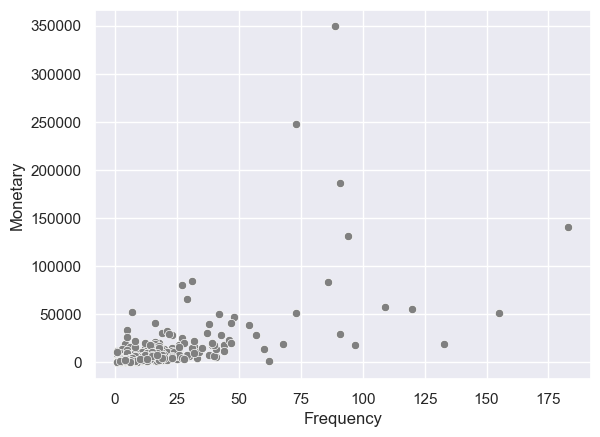

In [177]:
plt.figure()
sns.scatterplot(data= seg_df, x='Frequency', y= 'Monetary', color= 'gray')
plt.show()

**splitting outliers for later preprocess**

In [178]:
# Function to get bounds and outliers
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (df[column] < lower) | (df[column] > upper)

# 1 & 2. Capture outliers in separate DataFrames
freq_mask = find_outliers(seg_df, 'Frequency')
mon_mask = find_outliers(seg_df, 'Monetary')

freq_outliers_df = seg_df[freq_mask].copy()
monetary_outliers_df = seg_df[mon_mask].copy()

# 3. Filter seg_df (keeping only those NOT in either outlier group)
seg_df = seg_df[~(freq_mask | mon_mask)].reset_index(drop=True)

### Model Selection

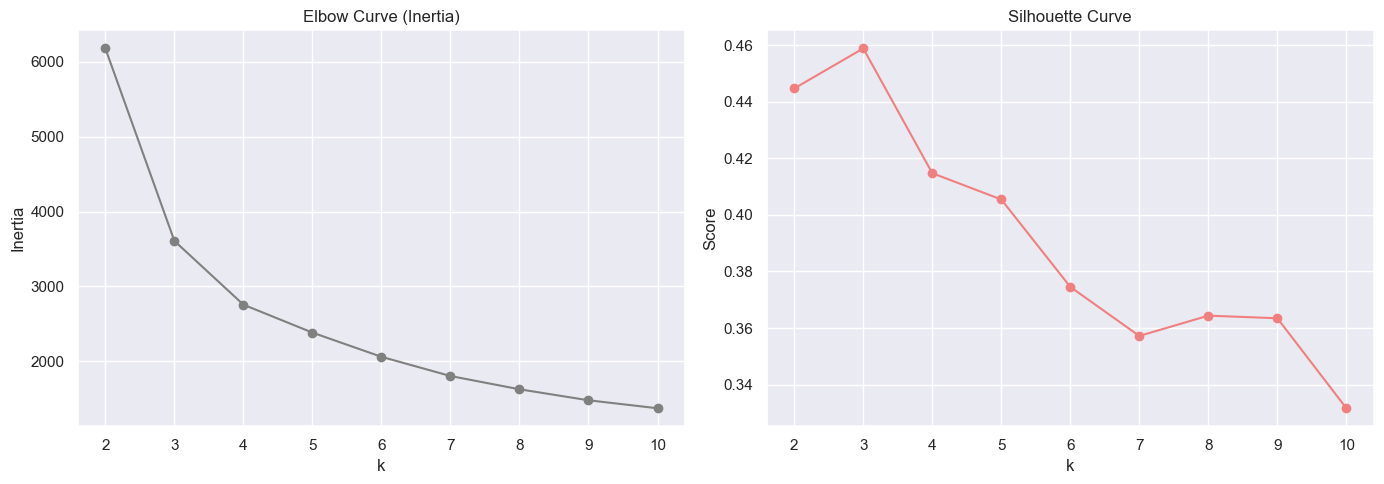

In [179]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# 1. Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(seg_df)

# 2. Iterate through k values
ks = range(2, 11)
inertia, silhouette_scores = [], []

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(scaled_data)
    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, model.labels_))

# 3. Aesthetics and Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ks, inertia, marker='o', color='grey')
ax1.set_title('Elbow Curve (Inertia)')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')

ax2.plot(ks, silhouette_scores, marker='o', color='lightcoral')
ax2.set_title('Silhouette Curve')
ax2.set_xlabel('k'); ax2.set_ylabel('Score')

plt.tight_layout()
plt.savefig('cluster_selection.png')

In [180]:
# 1. Initialize and fit KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)

# 2. Attach labels to the original (unscaled) seg_df
seg_df['Cluster'] = cluster_labels

# 3. View the first few rows
seg_df.head(4)

,Recency,Frequency,Monetary,Cluster
0,165,2,169.36,0
1,3,2,1323.32,3
2,74,1,221.16,1
3,43,2,2221.14,3


### Visualizing

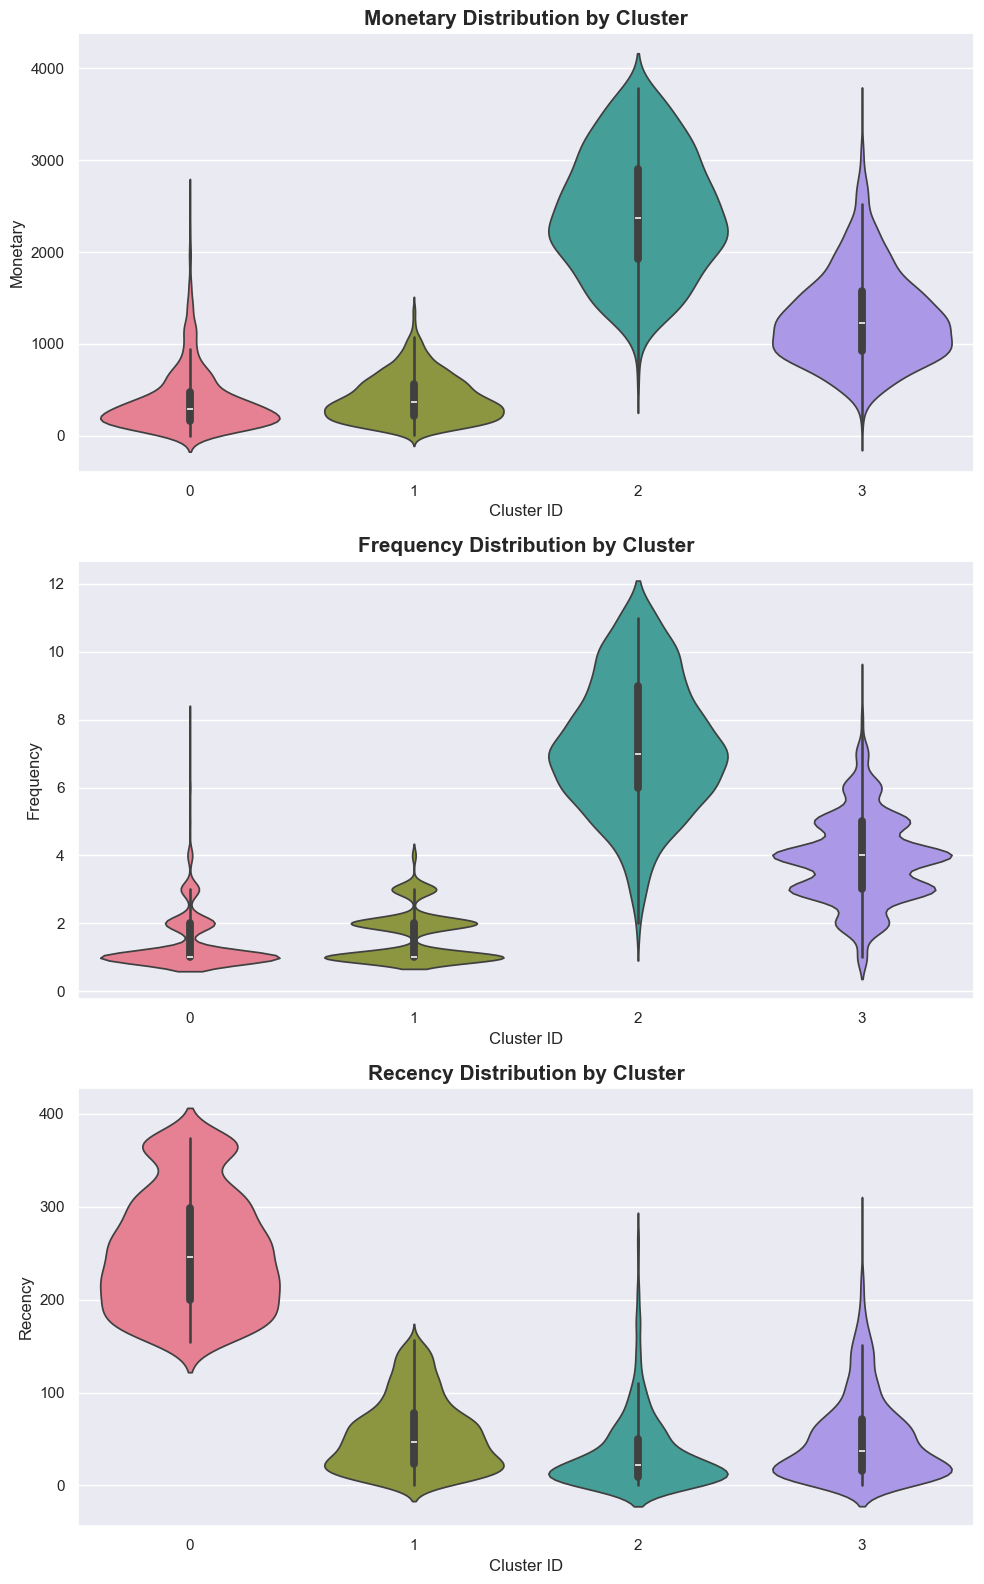

In [181]:
# 1. Define a consistent palette for the 4 clusters
custom_palette = sns.color_palette("husl", 4) 

# 2. Setup the figure (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(10, 16))
metrics = ['Monetary', 'Frequency', 'Recency']
titles = ['Monetary Distribution', 'Frequency Distribution', 'Recency Distribution']

# 3. Loop through to ensure consistency and clean code
for i, metric in enumerate(metrics):
    sns.violinplot(
        x='Cluster', 
        y=metric, 
        data=seg_df, 
        hue='Cluster', 
        palette=custom_palette, 
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f'{titles[i]} by Cluster', fontsize=15, fontweight='bold')
    axes[i].set_xlabel('Cluster ID')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

In [182]:
# 1. Update Mapping
cluster_mapping = {
    2: {'Segment': 'Champions', 'Rank': 1, 'Color': 'Light Green', 
        'Strategy': 'VIP Priority: Ensure 100% stock availability and offer Early Access.'},
    3: {'Segment': 'Loyal Moderate-Spenders', 'Rank': 2, 'Color': 'Very Light Green', 
        'Strategy': 'Cross-sell/Up-sell: Recommend high-end items or bundles.'},
    1: {'Segment': 'Lapsed Low-Spenders', 'Rank': 3, 'Color': 'Light Yellow', 
        'Strategy': 'Retention via "Buy 2 Get 1": Increase frequency.'},
    0: {'Segment': 'Lost Customers', 'Rank': 4, 'Color': 'Light Red', 
        'Strategy': 'Win-back "Hail Mary": One-time deep discount.'}
}

# 2. Data Integration
seg_df['Segment'] = seg_df['Cluster'].map(lambda x: cluster_mapping[x]['Segment'])

# 3. Create Summary Table
pd.set_option('display.max_colwidth', None)
strategy_summary = pd.DataFrame.from_dict(cluster_mapping, orient='index').sort_values('Rank')

# 4. Corrected Styling Function with Dark Text
def apply_row_colors(row):
    color_map = {
        'Light Green': 'background-color: #90EE90; color: #1a1a1a; font-weight: 500;',
        'Very Light Green': 'background-color: #E0FFE0; color: #1a1a1a; font-weight: 500;',
        'Light Yellow': 'background-color: #FFFFE0; color: #1a1a1a; font-weight: 500;',
        'Light Red': 'background-color: #FFC0CB; color: #1a1a1a; font-weight: 500;'
    }
    # Apply the specific CSS string to all cells in the row
    return [color_map.get(row['Color'], '')] * len(row)

# 5. Execute Styling
styled_summary = strategy_summary[['Rank', 'Segment', 'Color', 'Strategy']].style.apply(apply_row_colors, axis=1)
styled_summary

,Rank,Segment,Color,Strategy
2,1,Champions,Light Green,VIP Priority: Ensure 100% stock availability and offer Early Access.
3,2,Loyal Moderate-Spenders,Very Light Green,Cross-sell/Up-sell: Recommend high-end items or bundles.
1,3,Lapsed Low-Spenders,Light Yellow,"Retention via ""Buy 2 Get 1"": Increase frequency."
0,4,Lost Customers,Light Red,"Win-back ""Hail Mary"": One-time deep discount."


In [183]:
# 1. Calculate the actual numerical bounds from the data
Q1_f, Q3_f = seg_df['Frequency'].quantile([0.25, 0.75])
freq_upper = Q3_f + 1.5 * (Q3_f - Q1_f)

Q1_m, Q3_m = seg_df['Monetary'].quantile([0.25, 0.75])
mon_upper = Q3_m + 1.5 * (Q3_m - Q1_m)

# 2. Define labeling logic (Cluster ID and Name only)
def label_outliers(row):
    high_f = row['Frequency'] > freq_upper
    high_m = row['Monetary'] > mon_upper
    
    if high_f and high_m:
        return 6, 'Whale Enthusiasts'
    elif high_f:
        return 5, 'High Frequency Outliers'
    elif high_m:
        return 4, 'High Spenders Outliers'
    return None, None

# 3. Combine outliers, apply labels, and merge back
outliers_df = pd.concat([freq_outliers_df, monetary_outliers_df]).drop_duplicates()
outliers_df[['Cluster', 'Segment']] = outliers_df.apply(
    lambda x: pd.Series(label_outliers(x)), axis=1
)

# 4. Final join back to the main dataframe
seg_df = pd.concat([seg_df, outliers_df], ignore_index=True)

In [187]:
# 1. Update Mapping (Ensuring Cluster ID is a visible field)
cluster_mapping = {
    6: {'Cluster': 6, 'Segment': 'Whale Enthusiasts', 'Rank': 1, 'Color': 'Gold', 
        'Strategy': 'Top Tier: Dedicated account manager and personalized logistics for high-volume orders.'},
    4: {'Cluster': 4, 'Segment': 'High Spenders Outliers', 'Rank': 2, 'Color': 'Deep Sky Blue', 
        'Strategy': 'Luxury White-Glove: Direct access to luxury inventory and bespoke recommendations.'},
    5: {'Cluster': 5, 'Segment': 'High Frequency Outliers', 'Rank': 3, 'Color': 'Medium Purple', 
        'Strategy': 'Efficiency Focus: Provide bulk-buy automation and recurring order discounts.'},
    2: {'Cluster': 2, 'Segment': 'Champions', 'Rank': 4, 'Color': 'Light Green', 
        'Strategy': 'VIP Priority: Ensure 100% stock availability and offer Early Access.'},
    3: {'Cluster': 3, 'Segment': 'Loyal Moderate-Spenders', 'Rank': 5, 'Color': 'Very Light Green', 
        'Strategy': 'Cross-sell/Up-sell: Recommend high-end items or bundles based on history.'},
    1: {'Cluster': 1, 'Segment': 'Lapsed Low-Spenders', 'Rank': 6, 'Color': 'Light Yellow', 
        'Strategy': 'Retention via "Buy 2 Get 1": Focus on rebuilding frequency without margin loss.'},
    0: {'Cluster': 0, 'Segment': 'Lost Customers', 'Rank': 7, 'Color': 'Light Red', 
        'Strategy': 'Win-back "Hail Mary": One-time deep discount; discontinue if no engagement.'}
}

# 2. Create Summary Table and Sort by Rank
strategy_summary = pd.DataFrame.from_dict(cluster_mapping, orient='index').sort_values('Rank')

# 3. Styling with Dark Text and Consistent Rows
def apply_row_colors(row):
    color_map = {
        'Gold': 'background-color: #FFD700; color: #000000; font-weight: bold;',
        'Deep Sky Blue': 'background-color: #00BFFF; color: #ffffff; font-weight: bold;',
        'Medium Purple': 'background-color: #9370DB; color: #ffffff; font-weight: bold;',
        'Light Green': 'background-color: #90EE90; color: #1a1a1a;',
        'Very Light Green': 'background-color: #E0FFE0; color: #1a1a1a;',
        'Light Yellow': 'background-color: #FFFFE0; color: #1a1a1a;',
        'Light Red': 'background-color: #FFC0CB; color: #1a1a1a;'
    }
    return [color_map.get(row['Color'], '')] * len(row)

# 4. Display Final Table with Cluster Number
styled_summary = strategy_summary[['Rank', 'Cluster', 'Segment', 'Color', 'Strategy']].style\
    .apply(apply_row_colors, axis=1)\
    .hide(axis='index')

styled_summary

Rank,Cluster,Segment,Color,Strategy
1,6,Whale Enthusiasts,Gold,Top Tier: Dedicated account manager and personalized logistics for high-volume orders.
2,4,High Spenders Outliers,Deep Sky Blue,Luxury White-Glove: Direct access to luxury inventory and bespoke recommendations.
3,5,High Frequency Outliers,Medium Purple,Efficiency Focus: Provide bulk-buy automation and recurring order discounts.
4,2,Champions,Light Green,VIP Priority: Ensure 100% stock availability and offer Early Access.
5,3,Loyal Moderate-Spenders,Very Light Green,Cross-sell/Up-sell: Recommend high-end items or bundles based on history.
6,1,Lapsed Low-Spenders,Light Yellow,"Retention via ""Buy 2 Get 1"": Focus on rebuilding frequency without margin loss."
7,0,Lost Customers,Light Red,"Win-back ""Hail Mary"": One-time deep discount; discontinue if no engagement."
